## Задание Pro



1. Выберите 10 самых красивых по вашем мнению пятерок в тренировочной выборке mnist.
2. Создайте датасет, где объекты – это все пятерки из тренировочной части mnist, а метки – это случайные пятерки из "красивого" набора.
3. Создайте автокодировщик и проверьте, совпадают ли у него размеры выхода и входа.
4. Обучите автокодировщик.
5. Добейтесь ошибки MSE на тренировочной выборке **<0.05**.
6. Посмотрите, как выглядят пятерки из тестовой выборки после обученного автокодировщика.

## Импорт библиотек

In [ ]:
# Для операций с тензорами
import numpy as np

# Для отрисвоки
import matplotlib.pyplot as plt

# Для создания модели
from tensorflow.keras.models import Model

# Необходимые слои
from tensorflow.keras.layers import Input, Conv2DTranspose, MaxPooling2D, Conv2D, BatchNormalization

# Слои для латентного пространства модели
from tensorflow.keras.layers import Flatten, Reshape, Dense

# Оптимизатор
from tensorflow.keras.optimizers import Adam

# Для загрузки базы
from tensorflow.keras.datasets import mnist

## Загрузка данных

In [ ]:
# Загрузка датасета
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Нормализация данных
X_train = X_train.astype('float32')/255.
X_test = X_test.astype('float32')/255.

In [ ]:
# Приведение формы к удобной для Keras
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [ ]:
# Отбор пятерок
mask = y_train == 5
X_train = X_train[mask]
y_train = y_train[mask]

In [ ]:
# Аналогично для тестирования
mask = y_test == 5
X_test = X_test[mask]
y_test = y_test[mask]

## Отбор красивых пятерок

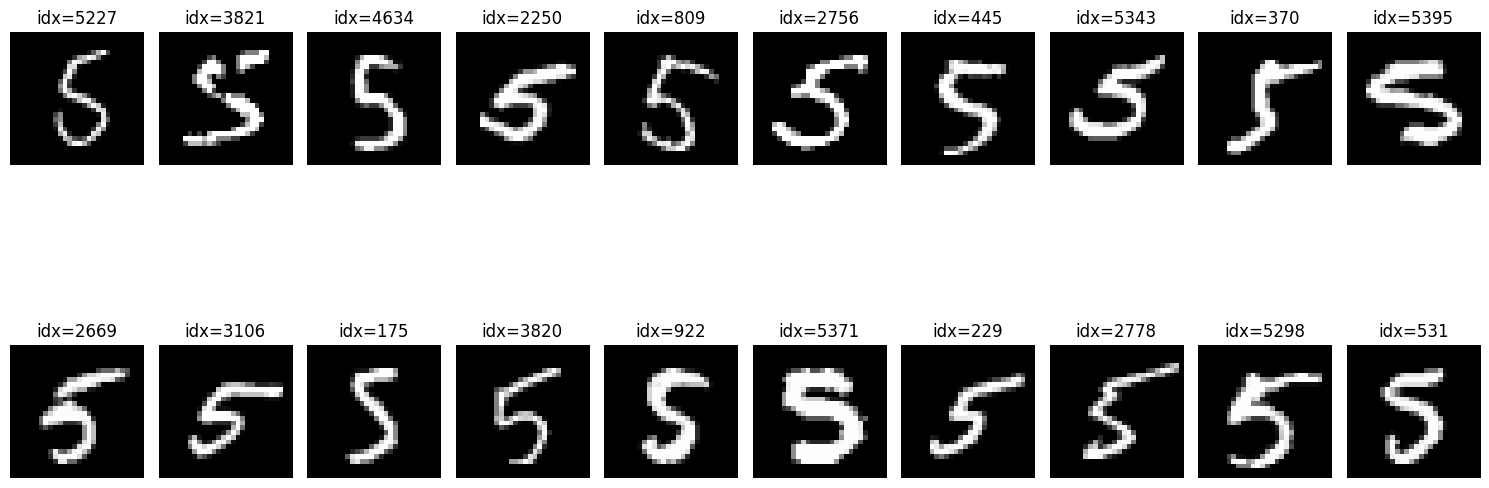

Выбрано 10 красивых пятерок
Форма набора красивых пятерок: (10, 28, 28, 1)


In [ ]:
# Визуализируем случайные пятерки и выбираем красивые вручную
plt.figure(figsize=(15, 8))
for i in range(20):
    idx = np.random.randint(0, len(X_train))
    plt.subplot(2, 10, i+1)
    plt.imshow(X_train[idx].squeeze(), cmap='gray')
    plt.title(f'idx={idx}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# После визуализации выбераем индексы красивых пятерок
beautiful_indices = [3860, 2140, 1680, 3605, 5059, 5068, 1191, 3673, 4437, 3957]
X_beautiful = X_train[beautiful_indices]
print(f"Выбрано {len(X_beautiful)} красивых пятерок")
print(f"Форма набора красивых пятерок: {X_beautiful.shape}")

In [ ]:
y_beautiful = X_train

## Создание модели

In [ ]:
def create_autoencoder():
    img_input = Input(shape=(28, 28, 1))

    # Энкодер
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(img_input)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Flatten()(x)
    latent = Dense(256, activation='relu')(x)
    latent = Dense(128, activation='relu')(latent)

    # Декодер
    x = Dense(128, activation='relu')(latent)
    x = Dense(4 * 4 * 128, activation='relu')(x)
    x = Reshape((4, 4, 128))(x)

    x = Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu', padding='same')(x)
    x = Conv2DTranspose(32, (3, 3), strides=(2, 2), activation='relu', padding='same')(x)
    x = Conv2DTranspose(1, (3, 3), strides=(2, 2), activation='sigmoid', padding='same')(x)

    from tensorflow.keras.layers import Cropping2D
    x = Cropping2D(cropping=((2, 2), (2, 2)))(x)

    model = Model(inputs=img_input, outputs=x)
    return model

autoencoder = create_autoencoder()
autoencoder.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 2048)           │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_14 (Reshape)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_42             │ (None, 8, 8, 64)       │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_43             │ (None, 16, 16, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_44             │ (None, 32, 32, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d_13 (Cropping2D)      │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,023,361 (3.90 MB)

 Trainable params: 1,023,361 (3.90 MB)

 Non-trainable params: 0 (0.00 B)

## Обучение модели

In [ ]:
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history = autoencoder.fit(
    X_train, y_beautiful,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 300ms/step - loss: 0.1403 - val_loss: 0.1033
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 254ms/step - loss: 0.0994 - val_loss: 0.0974
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 262ms/step - loss: 0.0759 - val_loss: 0.0625
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 292ms/step - loss: 0.0606 - val_loss: 0.0564
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 295ms/step - loss: 0.0514 - val_loss: 0.0486
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 272ms/step - loss: 0.0454 - val_loss: 0.0442
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 273ms/step - loss: 0.0422 - val_loss: 0.0422
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 305ms/step - loss: 0.0401 - val_loss: 0.0388
Epoch 9/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 296ms/step - loss: 0.0351 - val_loss: 0.0337
Epoch 10/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 278ms/step - loss: 0.0316 - val_loss: 0.0318
Epoch 11/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 264ms/step - loss: 0.0294 - val_loss: 0.0296
Epoch 12/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 296

## Вывод MSE

In [ ]:
train_pred = autoencoder.predict(X_train, verbose=0)
mse_train = np.mean((X_train - train_pred) ** 2)
print(f"MSE: {mse_train:.6f}")

MSE: 0.015967


## Пятерки из тестовой выборки после автокодировщика

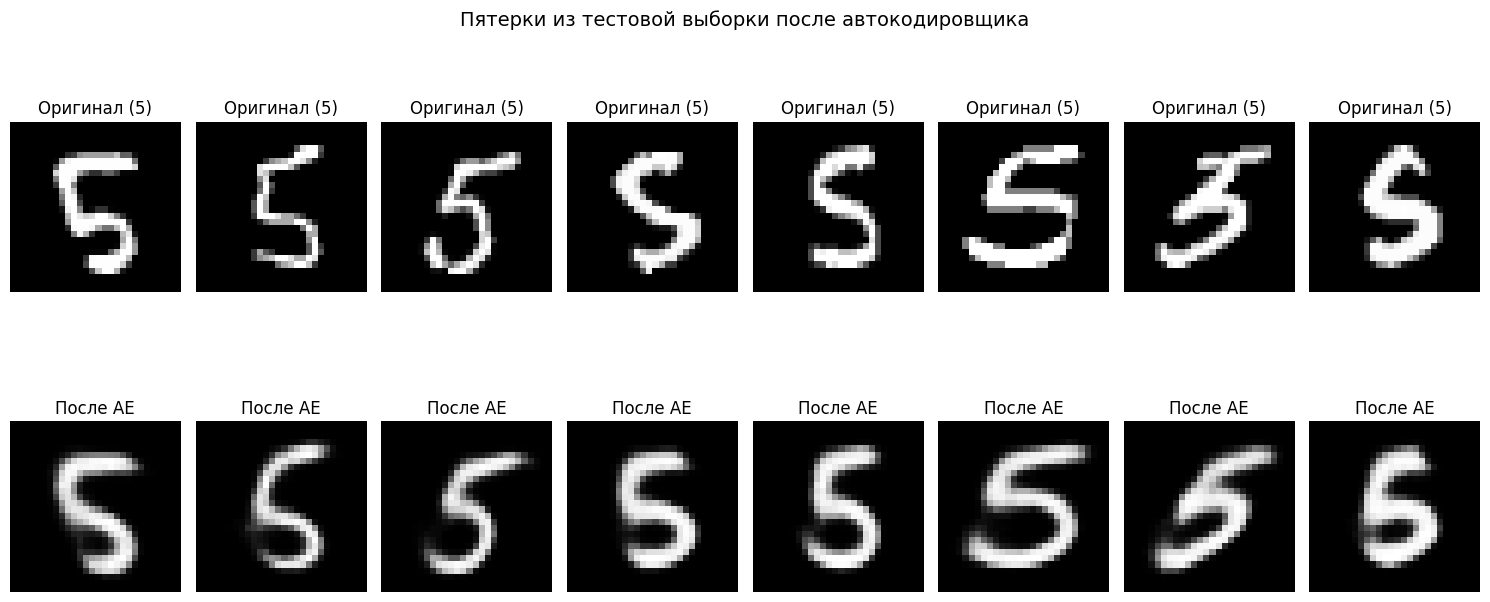

In [ ]:
# Предсказания для тестовых пятерок
test_pred = autoencoder.predict(X_test, verbose=0)

# Визуализация
plt.figure(figsize=(15, 10))
n = 8

for i in range(n):
    idx = np.random.randint(0, len(X_test))

    # Оригинал
    plt.subplot(3, n, i+1)
    plt.imshow(X_test[idx].squeeze(), cmap='gray')
    plt.title(f'Оригинал (5)')
    plt.axis('off')

    # Восстановленная пятерка
    plt.subplot(3, n, i+1+n)
    plt.imshow(test_pred[idx].squeeze(), cmap='gray')
    plt.title('После AE')
    plt.axis('off')

plt.suptitle('Пятерки из тестовой выборки после автокодировщика', fontsize=14)
plt.tight_layout()
plt.show()